### Experiment Set Ariadne

This experiment is about correlating deltas of out-of-distribution deltas and in-distribution deltas. The OOD samples are tuples (correct response, error augmented response), the ID samples are tuples (correct response, incorrect response with calc error).
The ID samples are per-checkpoint, we're evaluating all checkpoints on all samples (it's just easier for me to run the experiment this way... im lazy). Later on, we'll calculate the log-probabilities for (gt, aug) and (gt, err) and try to correlate along the checkpoints.
Formally, we're intersted about the correlation 

$\text{corr}(\Delta_{\text{ID}}, \Delta_{\text{OOD}})$

where $\Delta_{\text{ID}} = \{\Delta^0_{\text{ID}}, \Delta^{10}_{\text{ID}}, ..., \Delta^{80}_{\text{ID}}\}$. 

The deltas are computed as mean over per-query difference between augmented response $\hat y$ and anchor response $y$.

$$\quad \Delta^i_{\text{ID}} = \frac{1}{N}\sum_j^N \log p(\hat y_{ij}|x_{ij}) - \log p(y_{ij}|x_{ij})$$

What we'd like to observe: Decreasing likelihood delta for both sets of traces across training, a perfect correlation.
What would this result mean for my experiments? It would mean that I've shown empirically that for a single model, a single data type and a single augmentation (computation error) deltas of likelihoods for ID and OOD data correlate. It would give my previous experiments (and the ones I'm about to schedule) more weight.

What I'm likely to observe: Weak correlation or no correlation at all. This would mean that there is an effect present in either data which makes correlation hard. This could be a preference shift, pushing the OOD samples into regions where spurios effects dominate the likelihood of the trace.

What I'd be surprised to observe: Strong negative correlation. In this case, I'd have to look at the trends of the likelihoods themselves, not only the differences.

### About the experiment and the data preprocessing

At the core this experiment is about increasing trust in a method for measuring change in behaviour. At the core, we would like to measure change in behaviour but can't because it's prohibitively expensive to sample millions of traces and hard to classify them onto a taxonomy. If we instead could measure likelihoods of carefully constructed out-of-distribution samples and be certain that what we measure translates to behaviour observed in the ID model outputs, we could construct arbitrary behaviour-augmented traces (one may think of augmenting ground truths with certain reasoning strategies like divide and conquer for example) and measure the change relative to ground truths.

The issue is that by measuring likelihoods of static distributions over a set of checkpoints, we are measuring all kinds of effects - RLVR generally sharpens the models distribution, there is a preference shift towards a "problem solving output" distribution. This experiment correlates ID with OOD deltas, performing a negative test: If we see a negative correlation we can be sure that the method in itself is problematic. However: Seeing a positive correlation doesn't automatically mean the method is correct - there are still confounds even though I've given thought on how to alleviate them.

To this end, let me walk through the preprocessing steps to construct the ID and OOD pairs $(y, x)$.

#### ID samples

From a previous experiment (exp05), I've stored checkpoints of a Qwen2.5-7B model trained with GSPO on Dapo17k. The training was stable and performance as expected. From the validation rollouts of every checkpoint $i \in \{0, 10, 20, ..., 80\}$, where $i=0$ denotes the base model, I've taken the math500 rollouts to obtain 256 answers per question.

From these questions, I've built a subset of questions which have positive and (at least 3) negative rewarded traces in their set of answers. Note, that the set of questions and answers is chosen independently per checkpoint to maximize the space of possible candidates. From this subset, I've sampled 3 negative traces for further inspection. For these negative traces, I have to decide whether or not they contain a calculation error.

I've designed and iterated on a prompt for the classification process. I've settled on using Qwen3-8B for classification quite early, as i saw promising results and impressive reasoning capability. To evaluate a prompt, I've ran the experiments and chose 20 samples with a fixed seed, s.t. i may judge the model's outputs for a fixed set of diverse negative responses. I've chosen precision as the dominant metric for evaluation, as my plan is to filter for positive samples later on and I'd rather "loose" some positive samples (traces containing calculation errors) than muddy my final evaluation set. After a few iterations I've settled on a prompt which achieved 80% precision, which I deemed enough for this experiment.

From there on, I've collected and filtered the negative responses flagged as "calculation error" and mapped them back to their initial question. As the set of questions I've chosen also contained ID-positive samples, I could build pairs $(\text{correct response}, \text{false response containing calculation error})$ for the delta analysis.

#### OOD samples

To collect the OOD-samples I followed the standard recipe I plan to apply over model, data and algorithm dimensions later on. I've collected correct answers from the base model (checkpoint 0). I designed a strict augmentation prompt which fro a given ground truth $y$ lets me parse out a syntactically similar but error-augmented trace $\hat y$. I've judged the quality of generation and found the generated samples to be 1) of high quality and 2) to be close to their given ground truth in style. For example, a ground truth which contained a "divide and conquer" strategy where the model applied multiple steps, each pre-pended by a `#### Step X: Step Description` would result in the augmentation model replicating this specific form, but also inject a calculation error.

A previous problem was the occurence of artifacts within the augmented traces, where the augmented response contained reflections like "... (which is a calculation error) ..." or "... I (incorrectly) assume that ..." which I had to specifically avoid by mentioning this pattern in the prompt.


#### Update 19.12

- I've re-computed the OOD data per-checkpoint, i.e. make augmentations to ground truths across checkpoints. Let's plot those.

In [1]:
import os
import numpy as np
import pandas as pd

In [2]:
def load_delta_data(base_path : str) -> list[pd.DataFrame]:
    files = [
        os.path.join(base_path, x) for x in list(sorted(
            os.listdir(base_path), key=lambda x: x.split('_')[0]
        ))
    ]
    ret = []
    for fp in files:
        with open(fp, 'r') as file:
            ret.append(pd.read_json(file, lines=True))
    return ret

id_dfs = load_delta_data('/ptmp/rfechner/out/exp12/id_data__qwen2.5_7b__gspo/val_jsonl/')
ood_dfs = load_delta_data('/ptmp/rfechner/out/exp12/ood_data__qwen2.5_7b__gspo/val_jsonl/')
ood_pc_dfs = load_delta_data('/ptmp/rfechner/out/exp12/ood_data_per_checkpoint__qwen2.5_7b__gspo/val_jsonl/') # per-checkpoint

In [3]:
def splice_id_data(dfs : list[pd.DataFrame]) -> list[pd.DataFrame]:
    """
        For each dataframe we only keep the rows for which checkpoint_global_step == step
    """
    ret = []
    for df in dfs:
        ret.append(
            df[df['checkpoint_global_step'] == df['step']].copy()
        )
    return ret

def splice_id_data2(dfs : list[pd.DataFrame], step=0) -> list[pd.DataFrame]:
    """
        For each dataframe we only keep the rows for which step==`step`
    """
    ret = []
    for df in dfs:
        ret.append(
            df[df['step']==step].copy()
        )
    return ret

In [4]:
from typing import Tuple
def compute_plotting_values(id_dfs, ood_dfs) -> Tuple[list, list]:
    id_values, ood_values = [], []
    counter = 0
    # iterate over checkpoints
    for id_df, ood_df in zip(id_dfs, ood_dfs, strict=True):
        # group per question uid
        grouped_id, grouped_ood = id_df.groupby('uid', sort=False), ood_df.groupby('uid', sort=False)

        # per question, calculate the difference between augmentation and ground truth
        id_vs, ood_vs = [], []
        for uid, df in grouped_id:
            # ID samples possibly have multiple gt/aug traces per question
            aug = df[df['behaviour_type']=='calculation_error']['logprobs'].apply(lambda x: np.nanmean(x)).mean()
            anchor = df[df['behaviour_type']=='anchor']['logprobs'].apply(lambda x: np.nanmean(x)).mean()
            id_vs.append(aug - anchor)
        
        for uid, df in grouped_ood:
            aug = np.mean(df[df['behaviour_type']=='calculation_error']['logprobs'].iloc[0])
            anchor = np.mean(df[df['behaviour_type']=='anchor']['logprobs'].iloc[0])
            ood_vs.append(aug - anchor)
        id_values.append(np.nanmean(id_vs)); ood_values.append(np.nanmean(ood_vs))
    return id_values, ood_values

id_dfs_spliced = splice_id_data(id_dfs)
ood_dfs_spliced = splice_id_data(ood_pc_dfs)
id_values, ood_values = compute_plotting_values(id_dfs_spliced, ood_dfs_spliced)

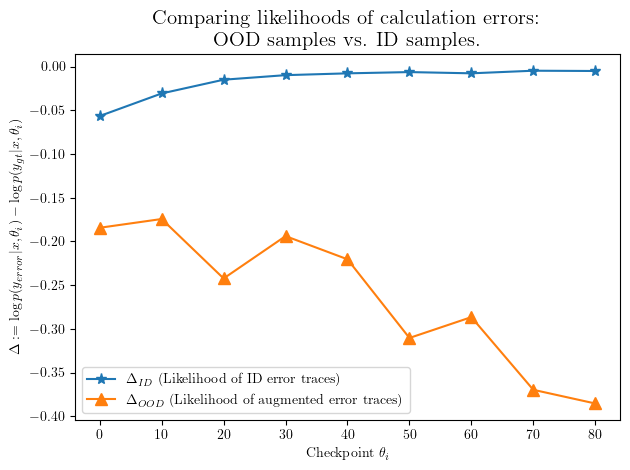

In [6]:
import matplotlib.pyplot as plt


# Enable LaTeX for all text
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
})

xs = np.arange(len(id_values)) * 10
plt.errorbar(x=xs, y=id_values, marker='*', markersize=8, label=r'$\Delta_{ID}$ (Likelihood of ID error traces)')
plt.errorbar(x=xs, y=ood_values, marker='^', markersize=8, label=r'$\Delta_{OOD}$ (Likelihood of augmented error traces)')
plt.title("Comparing likelihoods of calculation errors: \nOOD samples vs. ID samples.", fontsize=15)
plt.ylabel(r'$\Delta:= \log p(y_{error}|x, \theta_i) - \log p(y_{gt}|x, \theta_i)$ ')
plt.xlabel(r'Checkpoint $\theta_i$')
plt.legend()
plt.tight_layout()

plt.show()

In [7]:
id_dfs_spliced = splice_id_data2(id_dfs)
id_values, ood_values = compute_plotting_values(id_dfs_spliced, ood_dfs)

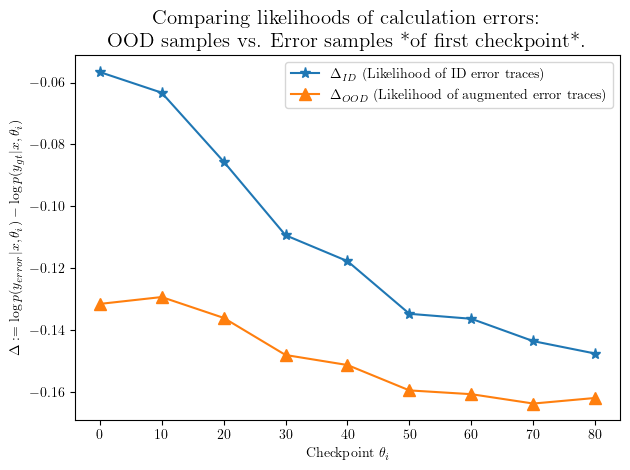

In [8]:
xs = np.arange(len(id_values)) * 10
plt.errorbar(x=xs, y=id_values, marker='*', markersize=8, label=r'$\Delta_{ID}$ (Likelihood of ID error traces)')
plt.errorbar(x=xs, y=ood_values, marker='^', markersize=8, label=r'$\Delta_{OOD}$ (Likelihood of augmented error traces)')
plt.title("Comparing likelihoods of calculation errors: \nOOD samples vs. Error samples *of first checkpoint*.", fontsize=15)
plt.ylabel(r'$\Delta:= \log p(y_{error}|x, \theta_i) - \log p(y_{gt}|x, \theta_i)$ ')
plt.xlabel(r'Checkpoint $\theta_i$')
plt.legend()
plt.tight_layout()

plt.show()

In [9]:
id_dfs_spliced = splice_id_data2(id_dfs, step=80)
id_values, ood_values = compute_plotting_values(id_dfs_spliced, ood_dfs)
xs = np.arange(len(id_values)) * 10
plt.errorbar(x=xs, y=id_values, marker='*', label=r'$\Delta_{\text{ID}}$')
plt.errorbar(x=xs, y=ood_values, marker='^', label=r'$\Delta_{\text{OOD}}$')
plt.legend()
plt.show()

RuntimeError: latex was not able to process the following string:
b'$\\\\Delta_{\\\\text{ID}}$'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmp3rgttj4m bb82d951e2075852a9a3a608e2bafeb62721c44d795610e87e5b852fc893eb68.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.22 (TeX Live 2021) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./bb82d951e2075852a9a3a608e2bafeb62721c44d795610e87e5b852fc893eb68.tex
LaTeX2e <2020-10-01> patch level 4
L3 programming layer <2021-02-18>
(/raven/u/system/soft/SLE_15/packages/x86_64/texlive/2021/2021/texmf-dist/tex/l
atex/base/article.cls
Document Class: article 2020/04/10 v1.4m Standard LaTeX document class

(/raven/u/system/soft/SLE_15/packages/x86_64/texlive/2021/2021/texmf-dist/tex/l
atex/base/size10.clo))
(/raven/u/system/soft/SLE_15/packages/x86_64/texlive/2021/2021/texmf-dist/tex/l
atex/type1cm/type1cm.sty)
(/raven/u/system/soft/SLE_15/package

<Figure size 640x480 with 1 Axes>

In [10]:
spliced = splice_id_data(id_dfs)
calculation_error_frequencies = [id_df.groupby('uid', sort=False).ngroups for id_df in spliced]

In [11]:
path = "/ptmp/rfechner/out/exp05_rollouts_qwen2.5-7b/qwen2.5_7b__gspo/val_jsonl"
sorted_files = [os.path.join(path, file) 
                for file in sorted(os.listdir(path), key=lambda x: int(x.split('_')[0]))]
print(sorted_files)
checkpoints = []
for file in sorted_files:
    with open(file, 'r') as jsonfile:
        cp = os.path.basename(file).split('_')[0]
        df = pd.read_json(jsonfile, lines=True)
        df['checkpoint'] = [cp] * len(df)
        checkpoints.append(df)

['/ptmp/rfechner/out/exp05_rollouts_qwen2.5-7b/qwen2.5_7b__gspo/val_jsonl/0_rollouts.jsonl', '/ptmp/rfechner/out/exp05_rollouts_qwen2.5-7b/qwen2.5_7b__gspo/val_jsonl/10_rollouts.jsonl', '/ptmp/rfechner/out/exp05_rollouts_qwen2.5-7b/qwen2.5_7b__gspo/val_jsonl/20_rollouts.jsonl', '/ptmp/rfechner/out/exp05_rollouts_qwen2.5-7b/qwen2.5_7b__gspo/val_jsonl/30_rollouts.jsonl', '/ptmp/rfechner/out/exp05_rollouts_qwen2.5-7b/qwen2.5_7b__gspo/val_jsonl/40_rollouts.jsonl', '/ptmp/rfechner/out/exp05_rollouts_qwen2.5-7b/qwen2.5_7b__gspo/val_jsonl/50_rollouts.jsonl', '/ptmp/rfechner/out/exp05_rollouts_qwen2.5-7b/qwen2.5_7b__gspo/val_jsonl/60_rollouts.jsonl', '/ptmp/rfechner/out/exp05_rollouts_qwen2.5-7b/qwen2.5_7b__gspo/val_jsonl/70_rollouts.jsonl', '/ptmp/rfechner/out/exp05_rollouts_qwen2.5-7b/qwen2.5_7b__gspo/val_jsonl/80_rollouts.jsonl']


In [12]:
# find out whether the percentage of calculation errors increases or decreases over the course of training
negative_rollouts = [sum(df['score'] <= 0) for df in checkpoints]

In [13]:
negative_rollouts

[109747, 84710, 75832, 70607, 67821, 67467, 66963, 67037, 65887]

In [14]:
# should get the ratio of sampled errors and flagged calculation errors.
# => sampled errors does 
calculation_error_frequencies

[261, 292, 239, 187, 165, 154, 148, 141, 117]

In [15]:
## get number of per-step error traces handed to judge.
with open('/u/rfechner/data/ariadne/id-prompts.parquet', 'rb') as file:
    idprompts = pd.read_parquet(file)

In [16]:
idprompts.columns

Index(['prompt', 'step', 'old_index'], dtype='object')

In [17]:
sampled_errors = idprompts.groupby('step', sort=False).apply(lambda g: len(g))

/tmp/ipykernel_129333/4229953296.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_errors = idprompts.groupby('step', sort=False).apply(lambda g: len(g))


In [18]:
sampled_errors = sampled_errors.sort_index()

In [19]:
# plot ratio between flagged calculation errors and sampled errors.
calc_error_ratio = np.array(calculation_error_frequencies) / np.array(sampled_errors)

In [20]:
calc_error_ratio

array([0.15591398, 0.16590909, 0.15954606, 0.15240424, 0.15054745,
       0.14694656, 0.14859438, 0.15031983, 0.14181818])

In [21]:
id_dfs_spliced = splice_id_data(id_dfs)
calc_error_id_values, calc_error_ood_values = compute_plotting_values(id_dfs_spliced, ood_dfs)

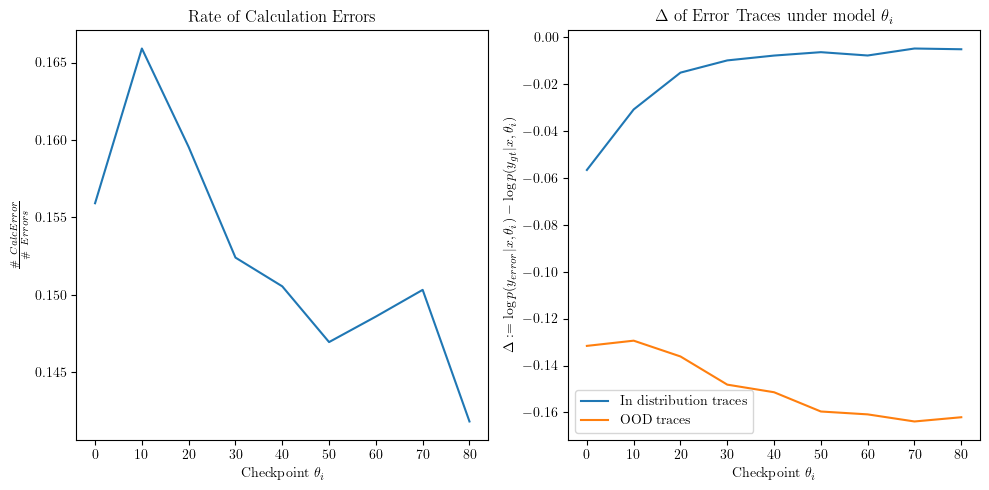

In [23]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
ax1.plot(np.arange(9) * 10, calc_error_ratio)
ax1.set_title('Rate of Calculation Errors')
ax1.set_xlabel('Checkpoint $\\theta_i$')
ax1.set_ylabel(r'$\frac{\#~Calc Error}{\#~Errors}$')

ax2.plot(xs, calc_error_id_values, label='In distribution traces')
ax2.plot(xs, calc_error_ood_values, label='OOD traces')
ax2.set_title('$\\Delta$ of Error Traces under model $\\theta_i$')
ax2.set_xlabel('Checkpoint $\\theta_i$')
ax2.set_ylabel(r'$\Delta:= \log p(y_{error}|x, \theta_i) - \log p(y_{gt}|x, \theta_i)$ ')


plt.legend()
plt.tight_layout()
plt.show()

### Behavior Type: Verification

In [24]:
ood_pc_verfiy_dfs = load_delta_data('/ptmp/rfechner/out/exp12/ood_data_verify__qwen2.5_7b__gspo/val_jsonl/') # per-checkpoint

In [25]:
# splice per-checkpoint
ood_pc_verify_spliced = splice_id_data(ood_pc_verfiy_dfs)

In [26]:
# per checkpoint, only leave in top 33 percent of most likely augmentations, i.e. augmentations which have the lowest delta to their
# ground truth counterpart
accu = []
for df in ood_pc_verify_spliced:
    deltas = df.groupby('uid', sort=False).apply(
        lambda g: np.array(g[g['behaviour_type'] == 'verification']['logprobs'].iloc[0]).mean() - \
            np.array(g[g['behaviour_type'] == 'anchor']['logprobs'].iloc[0]).mean()
    )
    df['delta'] = df['uid'].apply(lambda uid : deltas.loc[uid])
    accu.append(
        df[df['delta'] >= np.percentile(deltas, 66)]
    )

/tmp/ipykernel_129333/238738042.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  deltas = df.groupby('uid', sort=False).apply(
/tmp/ipykernel_129333/238738042.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  deltas = df.groupby('uid', sort=False).apply(
/tmp/ipykernel_129333/238738042.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future versi

In [27]:

# calculate the deltas:
ood_values = []
counter = 0
# iterate over checkpoints
for ood_df in accu:
    # group per question uid
    grouped_ood = ood_df.groupby('uid', sort=False)

    # per question, calculate the difference between augmentation and ground truth
    ood_vs = []
    for uid, df in grouped_ood:
        aug = np.mean(df[df['behaviour_type']=='verification']['logprobs'].iloc[0])
        anchor = np.mean(df[df['behaviour_type']=='anchor']['logprobs'].iloc[0])
        ood_vs.append(aug - anchor)
    ood_values.append(np.nanmean(ood_vs))


In [28]:
ood_values

[np.float64(-0.0932325296446449),
 np.float64(-0.08542375292845213),
 np.float64(-0.10390840122907033),
 np.float64(-0.11663114894986283),
 np.float64(-0.12196760023417695),
 np.float64(-0.1322894902623404),
 np.float64(-0.13794095778657323),
 np.float64(-0.15088669582668826),
 np.float64(-0.13304897640968683)]

In [29]:
# get fractions of verification prevalence
with open('/u/rfechner/data/ariadne/id-outputs-verify.parquet', 'rb') as file:
    id_outputs = pd.read_parquet(file)

In [30]:
def filter_in_distribution(df : pd.DataFrame) -> pd.DataFrame:
    """
        Parses and filters dataset.

        Responses of the in-distribution dataframe are of the shape:
        <think>...</think> ... #### {yes|no} ...
        We should filter out responses which contain a "#### yes"
    """
    def mapper(response : list[str]):
        r = response[0][-100:]
        try:
            i = r.rindex('####')
        except ValueError:
            return False
        return 'yes' in r[i:i+10]
        
    cond = df['responses'].apply(mapper)

    return df[cond]
pred = filter_in_distribution(id_outputs)

In [31]:
num_verified, total = pred.groupby('step').apply(len).to_numpy(), id_outputs.groupby('step').apply(len).to_numpy()
ratio = num_verified / total

/tmp/ipykernel_129333/3582978095.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  num_verified, total = pred.groupby('step').apply(len).to_numpy(), id_outputs.groupby('step').apply(len).to_numpy()
/tmp/ipykernel_129333/3582978095.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  num_verified, total = pred.groupby('step').apply(len).to_numpy(), id_outputs.groupby('step').apply(len).to_numpy()


In [32]:
ratio

array([0.11975591, 0.08437271, 0.07027818, 0.09404849, 0.1183432 ,
       0.12125749, 0.13262999, 0.14692308, 0.14926527])

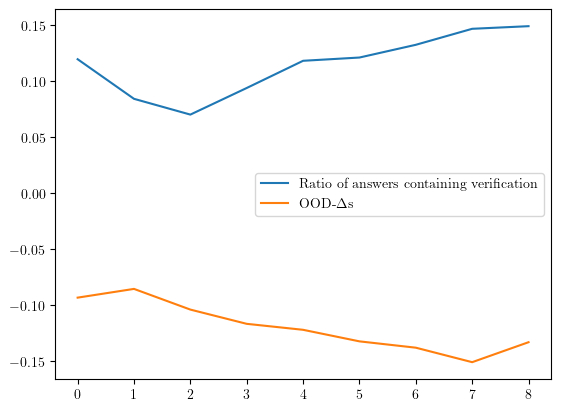

In [33]:
import matplotlib.pyplot as plt

plt.plot(ratio, label='Ratio of answers containing verification')
plt.plot(ood_values, label='OOD-$\\Delta$s')
plt.legend()
plt.show()

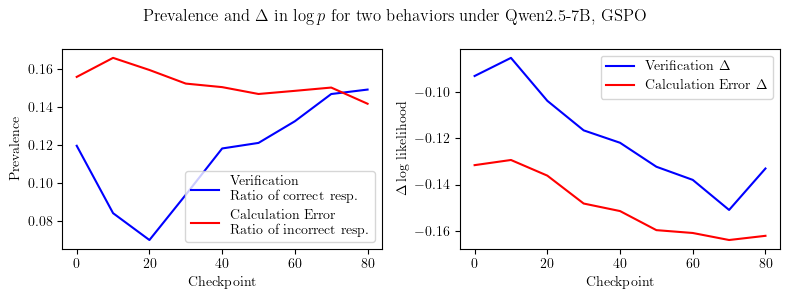

In [36]:
## thesis plots.
output_dir = '/u/rfechner/verl/plots/deltas'

fig, (ratio_ax, delta_ax) = plt.subplots(nrows=1, ncols=2, figsize=(8, 3))

validation_ratio = ratio
validation_ood_values = ood_values

xs = np.arange(len(validation_ratio)) # same for validation and error
xticks = xs * 10 # checkpoints
ratio_ax.plot(validation_ratio, color='blue', label='Verification\nRatio of correct resp.')
ratio_ax.plot(calc_error_ratio, color='red', label='Calculation Error\nRatio of incorrect resp.')
ratio_ax.set_xticks(xs[::2], xticks[::2])
ratio_ax.set_ylabel('Prevalence')
ratio_ax.set_xlabel('Checkpoint')
ratio_ax.legend(loc='lower right')

delta_ax.plot(validation_ood_values, color='blue', label='Verification $\\Delta$')
delta_ax.plot(calc_error_ood_values, color='red', label='Calculation Error $\\Delta$')
delta_ax.set_xticks(xs[::2], xticks[::2])
delta_ax.set_ylabel(r"$\Delta \log $ likelihood")
delta_ax.set_xlabel('Checkpoint')
delta_ax.legend()

plt.suptitle('Prevalence and $\\Delta$ in $\\log p$ for two behaviors under Qwen2.5-7B, GSPO')
plt.tight_layout()
outfile = f"ariadne_correlations.pdf"
fig.savefig(os.path.join(output_dir, outfile), format="pdf", bbox_inches="tight")
plt.show()